# **Probability of Default**

## **Introduction**

This notebook builds the **PD (Probability of Default)** model — the first component of the Expected Loss framework:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

**Dataset:** Lending Club accepted loans 2007–2018Q4 (~2.26M rows). Only loans with a definitive outcome — `fully_paid` (negative class) or `charged_off` (positive class) — are retained. Ambiguous statuses (`Current`, `Late`, `In Grace Period`) are excluded to avoid label noise.

**Target:** `is_default` — binary label derived from `loan_status`.

**Time-based split:** train on loans issued up to 2015, validate on 2016, test on 2017+. Random splitting would leak future information and inflate validation metrics — time-based splitting is the only methodologically sound approach for loan origination data.

**Preprocessing:** Winsorizer → StandardScaler for numeric features; WoE encoding for categorical features (`home_ownership`, `purpose`). WoE is fitted on training data only.

**Model:** XGBoost Classifier wwas selected after comparison against Logistic Regression and Random Forest. Hyperparameters tuned with Optuna (Bayesian search + MedianPruner). Decision threshold optimised for F1 on the validation set rather than using the default 0.5.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, PrecisionRecallDisplay, RocCurveDisplay, average_precision_score, brier_score_loss
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
from scipy.stats import ks_2samp
from sklearn.calibration import calibration_curve
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## **Get Data**

I read the raw CSV, preview its columns, and save it as a Parquet file for efficient reloading. This section only needs to run once — after the Parquet file is created, I load directly from it.

In [ ]:
data = pd.read_csv("accepted_2007_to_2018Q4.csv")
print(pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=5).columns.tolist())
data["id"] = data["id"].astype("string")
data.to_parquet("accepted.parquet", index=False)

## **Feature Selection Rationale**

The original Lending Club dataset contains more than 150 columns. For a PD model, the core constraint is **temporal consistency**: I can only use information available at origination. Post-origination variables (`recoveries`, `total_pymnt`, etc.) are excluded as they introduce leakage.

Selected variables satisfy three criteria: (1) observable at application time, (2) economically linked to default risk, and (3) allow efficient, scalable development.

## **Load Working Dataset**

In [3]:
df = pd.read_parquet("accepted.parquet", columns=[
    "loan_status",
    "funded_amnt",
    "annual_inc",
    "dti",
    "grade",
    "sub_grade",
    "int_rate",
    "emp_length",
    "home_ownership",
    "purpose",
    "term",
    "issue_d",
    "recoveries",
    "installment",
])

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 14 columns):
 #   Column          Dtype  
---  ------          -----  
 0   loan_status     object 
 1   funded_amnt     float64
 2   annual_inc      float64
 3   dti             float64
 4   grade           object 
 5   sub_grade       object 
 6   int_rate        float64
 7   emp_length      object 
 8   home_ownership  object 
 9   purpose         object 
 10  term            object 
 11  issue_d         object 
 12  recoveries      float64
 13  installment     float64
dtypes: float64(6), object(8)
memory usage: 241.5+ MB


loan_status           33
funded_amnt           33
annual_inc            37
dti                 1744
grade                 33
sub_grade             33
int_rate              33
emp_length        146940
home_ownership        33
purpose               33
term                  33
issue_d               33
recoveries            33
installment           33
dtype: int64

## **Custom Transformers**

All transformer classes are defined here, before any application. Each class is independently testable and designed to slot into a pipeline.

### **Column Name Cleaner**

In [5]:
class ColumnNameCleaner(BaseEstimator, TransformerMixin):
    #Standardize column names: lowercase, replace spaces with underscores.

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.strip().str.lower().str.replace(' ', '_')
        return X

### **Employment Length Transformer**

Converts `emp_length` strings to numeric values and fills missing entries with the training mode.

In [6]:
class EmpLengthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mode'):
        self.strategy = strategy
        self.fill_value = None

    def fit(self, X, y=None):
        if self.strategy == 'mode':
            temp_col = pd.Series(X).str.extract('(\d+)').astype(float)
            self.fill_value = temp_col.mode()[0]
        else:
            self.fill_value = 0
        return self

    def transform(self, X):
        s = pd.Series(X).copy()
        s = s.replace('< 1 year', '0')
        s = s.str.extract('(\d+)', expand=False)
        s = s.astype(float)
        s = s.fillna(self.fill_value)
        return s.values.reshape(-1, 1)

### **Categorical Cleaner**

Standardizes all object columns: lowercase, underscores, stripped leading underscores.

In [7]:
class CategoricalCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = (
                X[col]
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
                .str.lstrip('_')
            )
        return X

### **Term Transformer**

Extracts the numeric month value from `term`.

In [8]:
class TermTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.iloc[:, 0]) if isinstance(X, pd.DataFrame) else pd.Series(X)
        return s.str.extract('(\d+)', expand=False).astype(float)

### **Loan Status Cleaner → Binary Target**

Retains only loans with a definitive outcome (`fully_paid` = 0, `charged_off` = 1). Ambiguous statuses are excluded to avoid label noise.

In [9]:
class LoanStatusCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.target_map = {'fully_paid': 0, 'charged_off': 1}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy = X_copy[X_copy['loan_status'].isin(self.target_map.keys())]
        X_copy['is_default'] = X_copy['loan_status'].map(self.target_map)
        return X_copy

### **Grade / Sub-Grade Transformer**

I map sub-grades to a 1–35 ordinal scale. Since `grade` is fully redundant with `sub_grade_num`, both originals are dropped.

In [10]:
class GradeTransformer(BaseEstimator, TransformerMixin):
    """Maps sub-grade strings to an ordinal 1-35 numeric scale."""

    def __init__(self):
        grades = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
        # FIXED: (count-1)*5 + i  →  a1=1, a5=5, b1=6, ..., g5=35
        self.mapping = {
            f"{g}{i}": (count - 1) * 5 + i
            for count, g in enumerate(grades, 1)
            for i in range(1, 6)
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'sub_grade' in X.columns:
            X['sub_grade_num'] = X['sub_grade'].str.lower().map(self.mapping).fillna(0)
            X = X.drop(columns=[c for c in ['grade', 'sub_grade'] if c in X.columns])
        return X

### **Issue Date Transformer**

Parses `issue_d` and extracts `issue_d_year` and `issue_d_quarter`. These are used both in EDA and as the basis for the time-based train/val/test split.

In [11]:
class IssueDateTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column='issue_d', create_year=True, create_quarter=True, drop_original=False):
        self.column = column
        self.create_year = create_year
        self.create_quarter = create_quarter
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = pd.to_datetime(X[self.column], format='%b_%Y', errors='coerce')
        if self.create_year:
            X[f'{self.column}_year'] = X[self.column].dt.year
        if self.create_quarter:
            X[f'{self.column}_quarter'] = X[self.column].dt.to_period('Q')
        if self.drop_original:
            X = X.drop(columns=[self.column])
        return X

### **Winsorizer**

Before scaling, I cap extreme values at the 1st/99th percentile. A single outlier like `annual_inc = 9,000,000` would otherwise distort `StandardScaler`'s mean and std for the entire column. Winsorizing caps rather than removes, so no rows are lost. Percentiles are fitted on training data only and applied to all splits.

In [12]:
class Winsorizer(BaseEstimator, TransformerMixin):
    #Cap numeric features at fitted lower/upper percentiles.

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        for col in X_.columns:
            self.lower_bounds_[col] = X_[col].quantile(self.lower)
            self.upper_bounds_[col] = X_[col].quantile(self.upper)
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in X_.columns:
            X_[col] = X_[col].clip(
                lower=self.lower_bounds_.get(col),
                upper=self.upper_bounds_.get(col)
            )
        return X_.values

### **Weight of Evidence (WoE) Encoder**

In credit risk, WoE encoding is preferred over one-hot encoding for categorical features. Instead of creating dummy columns, each category is replaced strategically.

This has several advantages: it produces a single numeric column per feature (no dimensionality explosion), it's monotonically related to the log-odds (ideal for logistic regression), and it naturally handles low-frequency categories. Encoding is fitted on training data only, preventing target leakage.

I also compute **Information Value (IV)** per feature during fitting. IV quantifies how predictive a variable is: IV < 0.02 = useless, 0.02–0.1 = weak, 0.1–0.3 = medium, > 0.3 = strong.

In [13]:
class WoEEncoder(BaseEstimator, TransformerMixin):
    """
    Weight of Evidence encoder for binary classification.
    Fitted on training data only. Stores IV per column.
    """

    def __init__(self, smoothing=0.5):
        # smoothing avoids log(0) for rare categories
        self.smoothing = smoothing
        self.woe_maps_ = {}
        self.iv_ = {}

    def fit(self, X, y):
        X_ = pd.DataFrame(X).copy()
        y_ = pd.Series(y).values
        total_events = y_.sum()                      # total defaults (1s)
        total_non_events = len(y_) - total_events    # total non-defaults (0s)

        for col in X_.columns:
            stats = (
                pd.DataFrame({'cat': X_[col].values, 'target': y_})
                .groupby('cat')['target']
                .agg(['sum', 'count'])
                .rename(columns={'sum': 'events', 'count': 'total'})
            )
            stats['non_events'] = stats['total'] - stats['events']

            # Smoothed distributions
            stats['dist_events']     = (stats['events']     + self.smoothing) / (total_events     + self.smoothing)
            stats['dist_non_events'] = (stats['non_events'] + self.smoothing) / (total_non_events + self.smoothing)

            stats['woe'] = np.log(stats['dist_non_events'] / stats['dist_events'])
            stats['iv']  = (stats['dist_non_events'] - stats['dist_events']) * stats['woe']

            self.woe_maps_[col] = stats['woe'].to_dict()
            self.iv_[col] = stats['iv'].sum()

        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in X_.columns:
            # Unknown categories at inference get WoE = 0 (neutral)
            X_[col] = X_[col].map(self.woe_maps_[col]).fillna(0)
        return X_.values

    def iv_summary(self):
        """Returns a sorted DataFrame of Information Values per feature."""
        iv_df = pd.DataFrame(list(self.iv_.items()), columns=['feature', 'IV'])
        iv_df['predictive_power'] = pd.cut(
            iv_df['IV'],
            bins=[-np.inf, 0.02, 0.1, 0.3, np.inf],
            labels=['Useless', 'Weak', 'Medium', 'Strong']
        )
        return iv_df.sort_values('IV', ascending=False)

### **Feature Dropper**

In [14]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    #Drop specified columns from a DataFrame.

    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        existing_cols = [col for col in self.columns_to_drop if col in X.columns]
        return X.drop(columns=existing_cols)

## **Preprocessing**

I apply each transformer sequentially to `df`. The order matters:
column cleaning → type fixes → categorical standardization → target creation → encoding → dates.

After this section, `df` is the clean, leakage-free base I'll use for EDA and modeling.

In [15]:
df = ColumnNameCleaner().fit_transform(df)

In [16]:
df['emp_length'] = EmpLengthTransformer(strategy='mode').fit_transform(df['emp_length'])

In [17]:
space_count = (df == " ").sum()
print(f"Columns with whitespace-only entries:\n{space_count[space_count > 0]}")

Columns with whitespace-only entries:
Series([], dtype: int64)


In [18]:
df = CategoricalCleaner().fit_transform(df)

In [19]:
df['term'] = TermTransformer().fit_transform(df['term'])

In [20]:
df = LoanStatusCleaner().fit_transform(df)

In [21]:
df = GradeTransformer().fit_transform(df)

In [22]:
df = IssueDateTransformer(
    column='issue_d', create_year=True, create_quarter=True, drop_original=False
).fit_transform(df)

The df is now clean and ready. I verify the final structure before branching into EDA.

In [23]:
df.head()

,loan_status,funded_amnt,annual_inc,dti,int_rate,emp_length,home_ownership,purpose,term,issue_d,recoveries,installment,is_default,sub_grade_num,issue_d_year,issue_d_quarter
0,fully_paid,3600.0,55000.0,5.91,13.99,10.0,mortgage,debt_consolidation,36.0,2015-12-01,0.0,123.03,0,14,2015,2015Q4
1,fully_paid,24700.0,65000.0,16.06,11.99,10.0,mortgage,small_business,36.0,2015-12-01,0.0,820.28,0,11,2015,2015Q4
2,fully_paid,20000.0,63000.0,10.78,10.78,10.0,mortgage,home_improvement,60.0,2015-12-01,0.0,432.66,0,9,2015,2015Q4
4,fully_paid,10400.0,104433.0,25.37,22.45,3.0,mortgage,major_purchase,60.0,2015-12-01,0.0,289.91,0,26,2015,2015Q4
5,fully_paid,11950.0,34000.0,10.20,13.44,4.0,rent,debt_consolidation,36.0,2015-12-01,0.0,405.18,0,13,2015,2015Q4


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   loan_status      1345310 non-null  object        
 1   funded_amnt      1345310 non-null  float64       
 2   annual_inc       1345310 non-null  float64       
 3   dti              1344936 non-null  float64       
 4   int_rate         1345310 non-null  float64       
 5   emp_length       1266799 non-null  float64       
 6   home_ownership   1345310 non-null  object        
 7   purpose          1345310 non-null  object        
 8   term             1345310 non-null  float64       
 9   issue_d          1345310 non-null  datetime64[ns]
 10  recoveries       1345310 non-null  float64       
 11  installment      1345310 non-null  float64       
 12  is_default       1345310 non-null  int64         
 13  sub_grade_num    1345310 non-null  int64         
 14  issue_d

## **Exploratory Data Analysis**

This is not just about pretty charts — I'm looking for risk signals.

I compute `df_eda` so any columns I create for visualization stay isolated and don't mess with the main dataframe.

In [25]:
df_eda = df.copy()

### **Target Analysis — Class Imbalance Check**

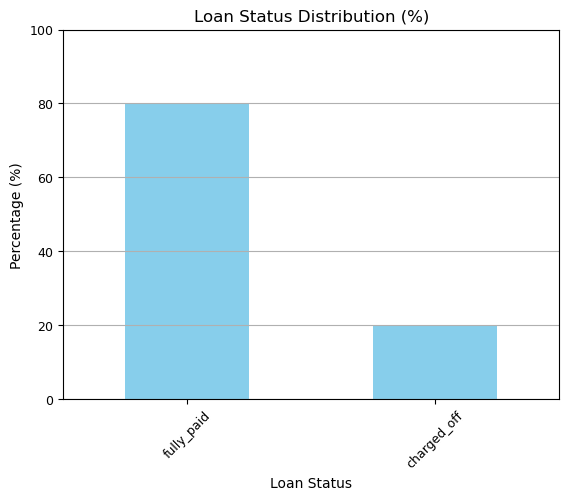

In [26]:
counts = df_eda['loan_status'].value_counts(normalize=True) * 100

counts.plot(kind='bar', color='skyblue', fontsize=9)
plt.title('Loan Status Distribution (%)')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y')
plt.show()

The dataset is imbalanced: ~80% fully paid, ~20% charged off. I'll handle this during modeling with `class_weight='balanced'` and threshold tuning on the validation set using the KS statistic (credit risk standard) rather than accuracy.

### **Risk Segmentation (Grades and Rates)**

#### **Grade Validation**

I check for monotonicity: default rate should increase consistently with `sub_grade_num`.

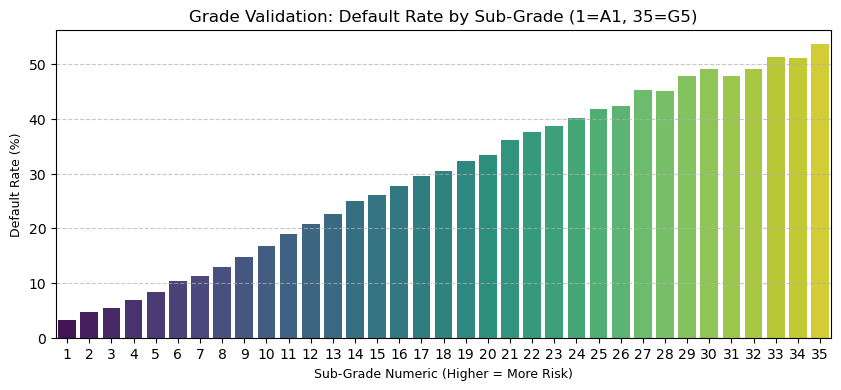

In [27]:
default_rates = df_eda.groupby('sub_grade_num')['is_default'].mean().reset_index()
default_rates['default_rate_pct'] = default_rates['is_default'] * 100

plt.figure(figsize=(10, 4))
sns.barplot(data=default_rates, x='sub_grade_num', y='default_rate_pct', palette='viridis')
plt.title('Grade Validation: Default Rate by Sub-Grade (1=A1, 35=G5)')
plt.xlabel('Sub-Grade Numeric (Higher = More Risk)', fontsize=9)
plt.ylabel('Default Rate (%)', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Perfect monotonicity.** Default rate increases consistently across all 35 sub-grade levels, confirming that `sub_grade_num` (now correctly encoded as a 1–35 ordinal) is a strong predictor.

#### **Interest Rates**

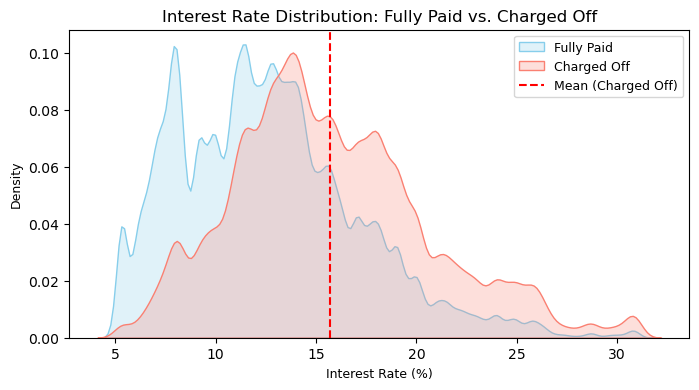

In [28]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_eda[df_eda['is_default'] == 0], x='int_rate',
            label='Fully Paid', fill=True, color='skyblue')
sns.kdeplot(data=df_eda[df_eda['is_default'] == 1], x='int_rate',
            label='Charged Off', fill=True, color='salmon')
plt.axvline(df_eda[df_eda['is_default'] == 1]['int_rate'].mean(),
            color='red', linestyle='--', label='Mean (Charged Off)')
plt.title('Interest Rate Distribution: Fully Paid vs. Charged Off')
plt.xlabel('Interest Rate (%)', fontsize=9)
plt.ylabel('Density', fontsize=9)
plt.legend(fontsize=9)
plt.show()

**The 'death cross' around 12.5–13%.** Below this threshold the fully-paid curve dominates; above it the charged-off curve takes over. This motivates the `int_rate_residual` interaction feature.

### **Repayment Capacity (DTI and Annual Income)**

#### **Debt-to-Income Ratio (DTI)**

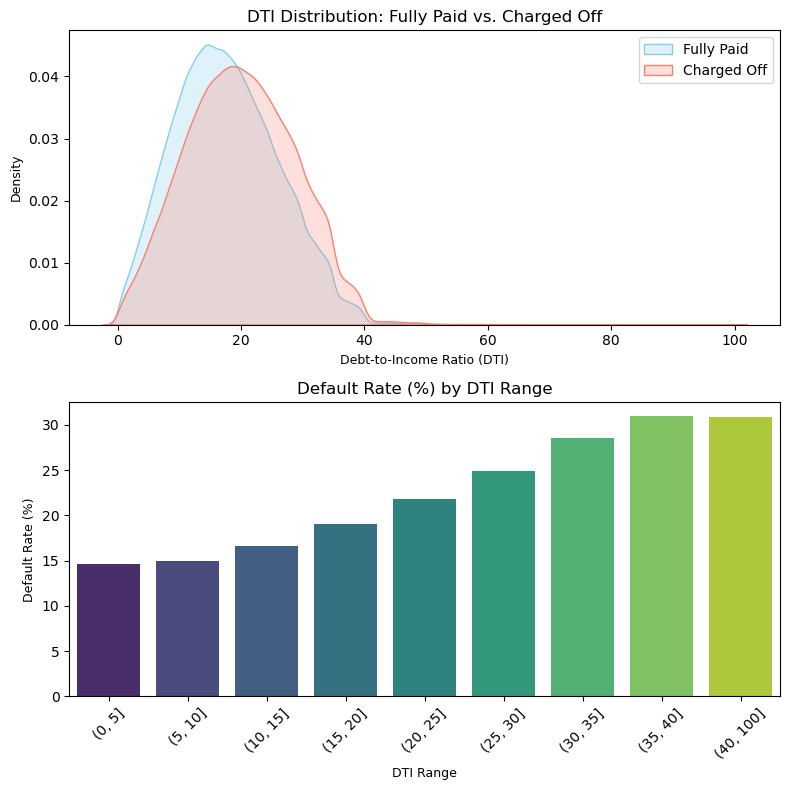

In [29]:
df_clean = df_eda[df_eda['dti'] <= 100]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

sns.kdeplot(data=df_clean[df_clean['is_default'] == 0], x='dti',
            label='Fully Paid', fill=True, color='skyblue', ax=ax1)
sns.kdeplot(data=df_clean[df_clean['is_default'] == 1], x='dti',
            label='Charged Off', fill=True, color='salmon', ax=ax1)
ax1.set_title('DTI Distribution: Fully Paid vs. Charged Off')
ax1.set_xlabel('Debt-to-Income Ratio (DTI)', fontsize=9)
ax1.set_ylabel('Density', fontsize=9)
ax1.legend()

df_eda['dti_range'] = pd.cut(df_eda['dti'], bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 100])
dti_impact = df_eda.groupby('dti_range', observed=False)['is_default'].mean().reset_index()
dti_impact['default_rate'] = dti_impact['is_default'] * 100

sns.barplot(data=dti_impact, x='dti_range', y='default_rate', palette='viridis', ax=ax2)
ax2.set_title('Default Rate (%) by DTI Range')
ax2.set_ylabel('Default Rate (%)', fontsize=9)
ax2.set_xlabel('DTI Range', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Clear positive correlation between DTI and default probability, validating both `dti` as a feature and the `dti_x_term` interaction (higher DTI + longer term = amplified repayment stress).

#### **Income vs. Loan Amount**

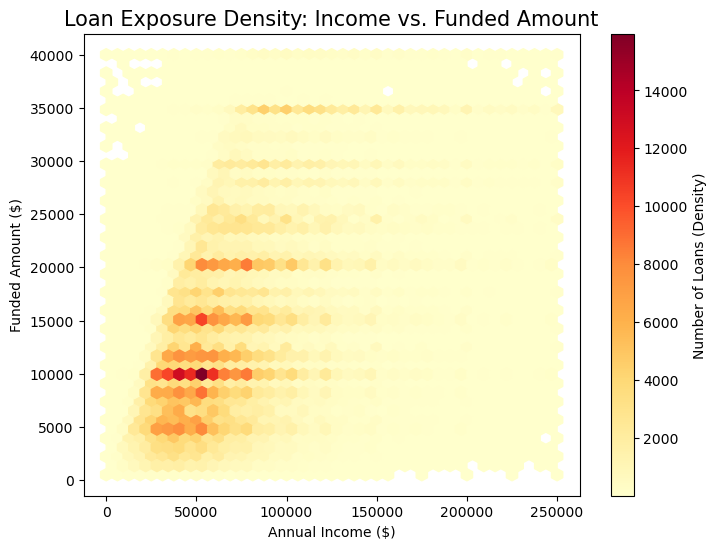

In [30]:
df_filtered = df_eda[(df_eda['annual_inc'] <= 250000) & (df_eda['funded_amnt'] <= 40000)]

plt.figure(figsize=(8, 6))
hb = plt.hexbin(df_filtered['annual_inc'], df_filtered['funded_amnt'],
                gridsize=40, cmap='YlOrRd', mincnt=1)
cb = plt.colorbar(hb)
cb.set_label('Number of Loans (Density)')
plt.title('Loan Exposure Density: Income vs. Funded Amount', fontsize=15)
plt.xlabel('Annual Income ($)')
plt.ylabel('Funded Amount ($)')
plt.show()

High concentration of exposure in the 40k-70k income bracket with loan amounts clustering around 10k–15k. This motivates `loan_to_income` and the `inc_stability` interaction feature.

### **Categorical Variables (Purpose and Home Ownership)**

#### **Loan Purpose**

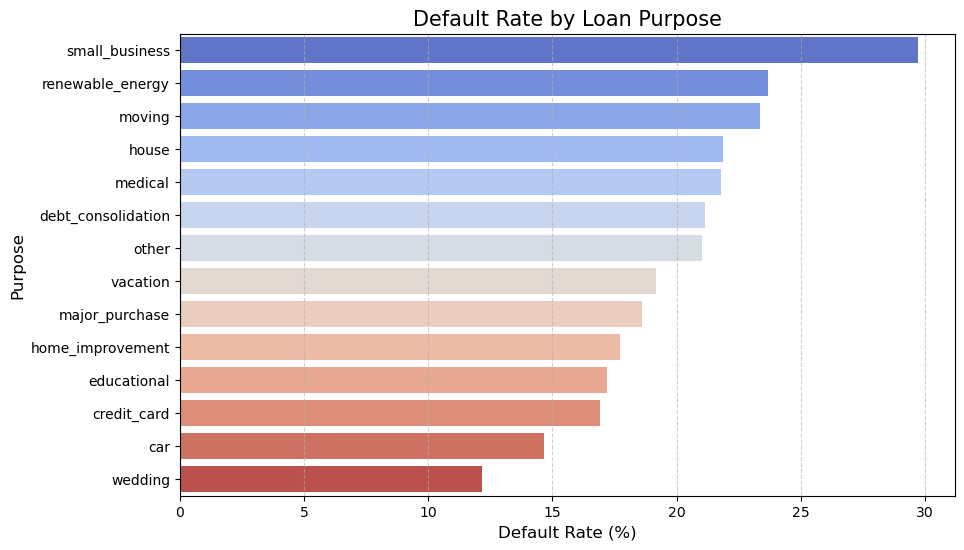

In [31]:
purpose_risk = (
    df_eda.groupby('purpose')['is_default']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
purpose_risk['default_rate_pct'] = purpose_risk['is_default'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=purpose_risk, x='default_rate_pct', y='purpose', palette='coolwarm')
plt.title('Default Rate by Loan Purpose', fontsize=15)
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Purpose', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

`small_business` is the highest-risk category, validating the `is_risky_purpose` flag. The clear risk stratification across purposes also confirms that WoE encoding will add signal here.

#### **Home Ownership**

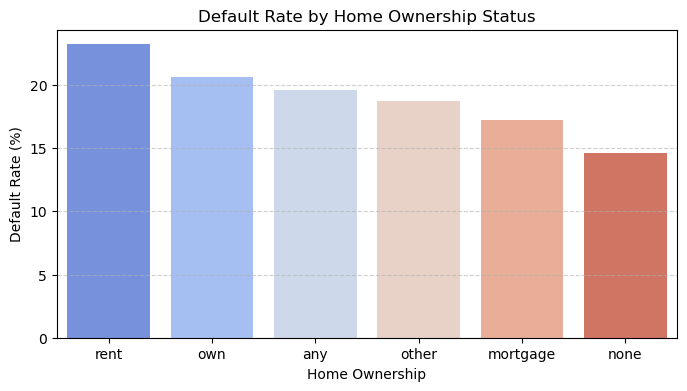

In [32]:
home_risk = (
    df_eda.groupby('home_ownership')['is_default']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
home_risk['default_rate_pct'] = home_risk['is_default'] * 100

plt.figure(figsize=(8, 4))
sns.barplot(data=home_risk, x='home_ownership', y='default_rate_pct', palette='coolwarm')
plt.title('Default Rate by Home Ownership Status')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### **Temporal Analysis**

#### **Lending Volume by Quarter**

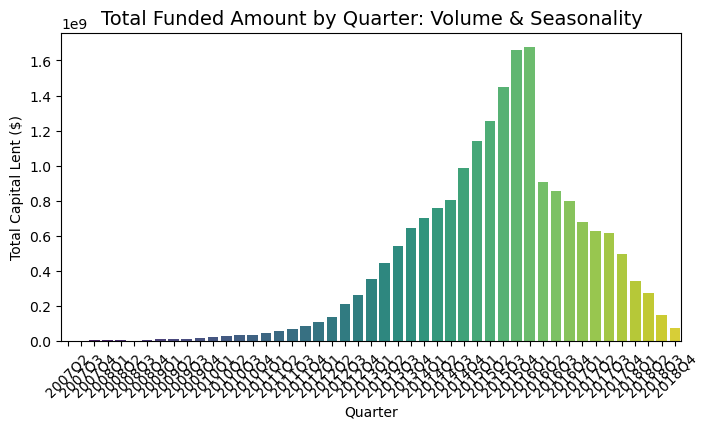

In [33]:
quarterly_funds = df_eda.groupby('issue_d_quarter')['funded_amnt'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=quarterly_funds, x='issue_d_quarter', y='funded_amnt', palette='viridis')
plt.title('Total Funded Amount by Quarter: Volume & Seasonality', fontsize=14)
plt.ylabel('Total Capital Lent ($)')
plt.xlabel('Quarter')
plt.xticks(rotation=45)
plt.show()

**Exponential growth (2007–2015):** Lending volume grew massively before plateauing. Early vintages have very different risk profiles — a key reason to use a time-based split.

#### **Pure Seasonality (Q1–Q4)**

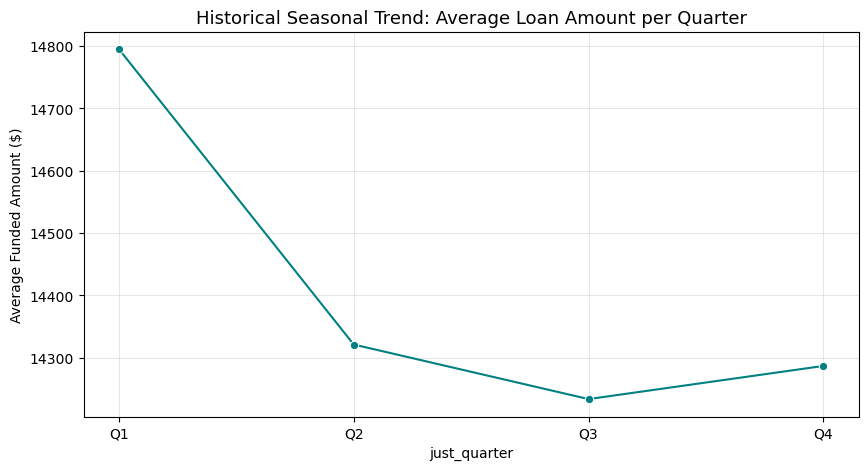

In [34]:
df_eda['just_quarter'] = df_eda['issue_d_quarter'].astype(str).str[-2:]
seasonal_trend = df_eda.groupby('just_quarter', observed=False)['funded_amnt'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=seasonal_trend, x='just_quarter', y='funded_amnt', marker='o', color='teal')
plt.title('Historical Seasonal Trend: Average Loan Amount per Quarter', fontsize=13)
plt.ylabel('Average Funded Amount ($)')
plt.grid(True, alpha=0.3)
plt.show()

**The Q1 effect:** Q1 shows the highest average loan amounts — likely borrowers consolidating debt or funding new ventures at the start of the year.

#### **Risk Stability Over Time: Grade × Quarter Heatmap**

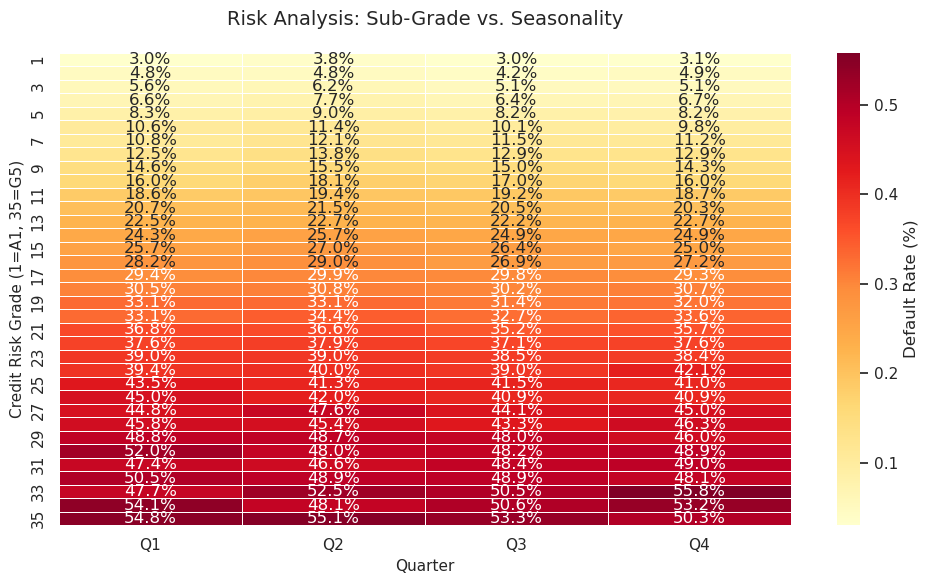

In [35]:
sns.set_theme(style='white')
plt.rcParams['figure.dpi'] = 100

risk_matrix = df_eda.pivot_table(
    index='sub_grade_num',
    columns='just_quarter',
    values='is_default',
    aggfunc='mean',
    observed=False
)

plt.figure(figsize=(10, 6))
sns.heatmap(risk_matrix, annot=True, fmt='.1%', cmap='YlOrRd',
            linewidths=.5, cbar_kws={'label': 'Default Rate (%)'})
plt.title('Risk Analysis: Sub-Grade vs. Seasonality', fontsize=14, pad=20)
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Credit Risk Grade (1=A1, 35=G5)', fontsize=11)
plt.tight_layout()
plt.show()

**Risk stability confirmed.** Default rates are consistent across quarters for each sub-grade, no seasonal distortion in risk composition. Good for model generalization.

#### **Interest Rate Evolution Over Time**

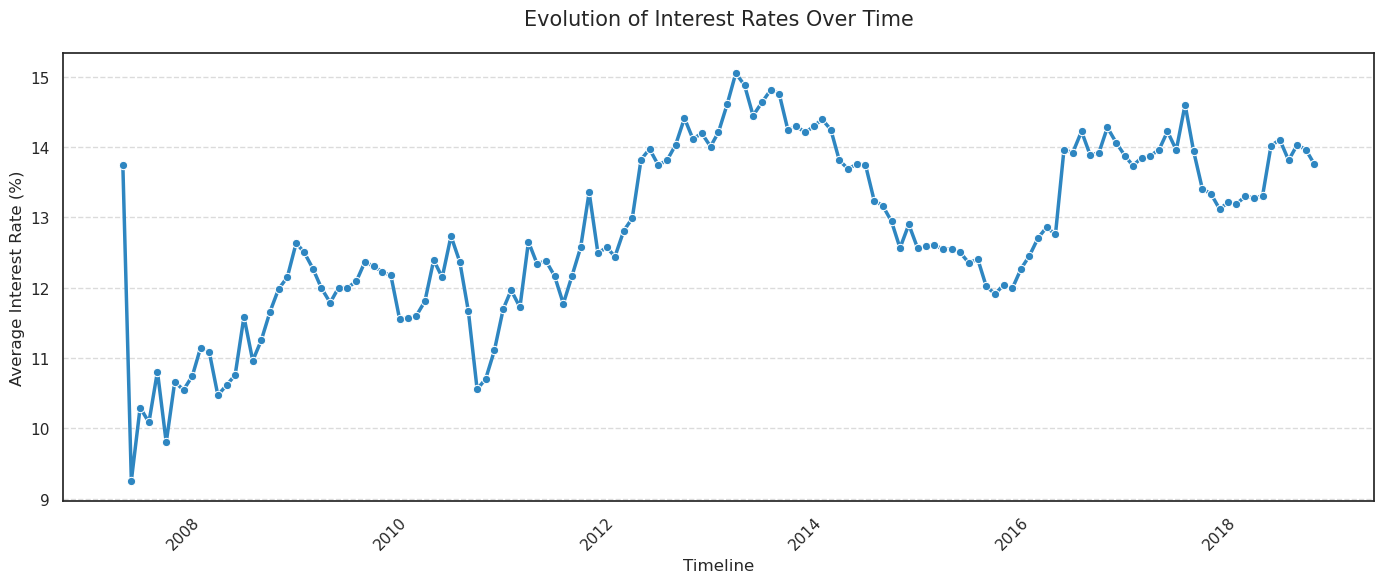

In [36]:
interest_trend = df_eda.groupby('issue_d')['int_rate'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=interest_trend, x='issue_d', y='int_rate',
             marker='o', color='#2E86C1', linewidth=2.5)
plt.title('Evolution of Interest Rates Over Time', fontsize=15, pad=20)
plt.ylabel('Average Interest Rate (%)', fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Correlations**

#### **Correlation Heatmap (Numeric Features)**

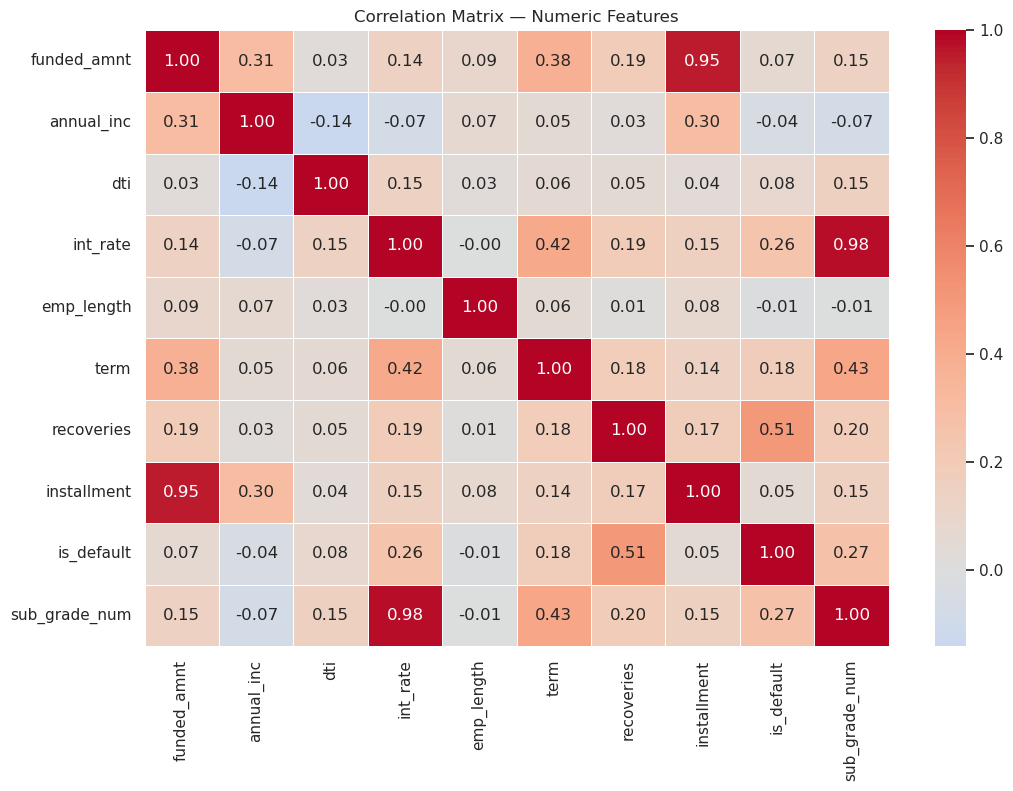

In [37]:
df_numeric = df_eda.select_dtypes(include=['float64', 'int64'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

Key observations:

- **`funded_amnt` vs. `installment` (≈0.95):** High multicollinearity — `installment` is dropped before modeling. Note: this is a multicollinearity decision, not a leakage decision. `installment` is known at origination and is not leakage.
- **`int_rate` vs. `sub_grade_num` (high):** Both encode risk, but `int_rate_residual` (borrower rate minus grade mean) captures the incremental signal beyond what the grade already implies.
- **`recoveries` vs. `is_default`:** This is leakage — `recoveries` is only known post-default. Dropped before training.

## **Prepare Data for Modeling**

EDA is complete. I return to the clean dataframe and build the full feature engineering + preprocessing pipeline, then perform a **time-based split**.

### **Column Definitions**

In [38]:
# Columns to drop: leakage or redundant
# - recoveries: leakage — only known after default occurs
# - installment: multicollinearity with funded_amnt (r≈0.95)
# - issue_d: raw date string, replaced by year/quarter features
# - loan_status: original label, replaced by is_default
# - issue_d_quarter: kept as string for split logic, dropped before training
COLS_TO_DROP = ['recoveries', 'installment', 'issue_d', 'loan_status', 'issue_d_quarter']

# Features that go through Winsorizer → StandardScaler
NUMERIC_FEATURES = [
    'funded_amnt', 'annual_inc', 'dti', 'int_rate',
    'emp_length', 'term', 'sub_grade_num'
]

# Features that go through WoE encoding
CATEGORICAL_FEATURES = ['home_ownership', 'purpose']

# Target
TARGET = 'is_default'

### **Feature Engineering**

#### **Loan Feature Engineer**

Economically motivated features derived from EDA findings, plus three new **interaction terms**:

- `dti_x_term`: DTI × loan term — a high DTI on a 60-month loan is more dangerous than on a 36-month one; the longer window amplifies repayment stress.
- `int_rate_residual`: borrower's rate minus the mean rate for their sub-grade — a positive residual means the market priced this loan as riskier than its grade suggests.
- `inc_stability`: log income × employment length — high income with low tenure is a different risk profile than high income with long tenure.

In [39]:
class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, create_log_income=True):
        self.create_log_income = create_log_income
        self._mean_rate_by_grade = None

    def fit(self, X, y=None):
        # Fit the mean int_rate per sub_grade_num on training data only
        if 'sub_grade_num' in X.columns and 'int_rate' in X.columns:
            self._mean_rate_by_grade = (
                X.groupby('sub_grade_num')['int_rate'].mean()
            )
        return self

    def transform(self, X):
        X = X.copy()

        # --- Original features ---
        X['loan_to_income']  = X['funded_amnt'] / (X['annual_inc'] + 1)
        X['payment_burden']  = (X['installment'] * 12) / (X['annual_inc'] + 1)

        if self.create_log_income:
            X['log_annual_inc'] = np.log1p(X['annual_inc'])

        if 'purpose' in X.columns:
            X['is_risky_purpose'] = np.where(X['purpose'] == 'small_business', 1, 0)

        # --- Interaction terms ---

        # DTI × Term: repayment stress amplified by loan duration
        if 'dti' in X.columns and 'term' in X.columns:
            X['dti_x_term'] = X['dti'] * X['term']

        # Int Rate Residual: how much more (or less) the borrower pays vs. grade peers
        if self._mean_rate_by_grade is not None:
            expected_rate = X['sub_grade_num'].map(self._mean_rate_by_grade)
            X['int_rate_residual'] = X['int_rate'] - expected_rate

        # Income Stability: high income only matters if employment is also stable
        if 'log_annual_inc' in X.columns and 'emp_length' in X.columns:
            X['inc_stability'] = X['log_annual_inc'] * X['emp_length']

        return X

In [40]:
# Apply feature engineering to df before splitting
# Note: fit_transform here is fine because we fit the int_rate_residual mean on the full
# pre-split dataset. After the split, the LoanFeatureEngineer inside the pipeline
# will be re-fitted on training data only.
fe = LoanFeatureEngineer(create_log_income=True)
df = fe.fit_transform(df)

# Update numeric feature list with engineered features
ENGINEERED_NUMERIC = [
    'loan_to_income', 'payment_burden', 'log_annual_inc',
    'dti_x_term', 'int_rate_residual', 'inc_stability'
]
ALL_NUMERIC = NUMERIC_FEATURES + ENGINEERED_NUMERIC

df.head()

,loan_status,funded_amnt,annual_inc,dti,int_rate,emp_length,home_ownership,purpose,term,issue_d,recoveries,installment,is_default,sub_grade_num,issue_d_year,issue_d_quarter,loan_to_income,payment_burden,log_annual_inc,is_risky_purpose,dti_x_term,int_rate_residual,inc_stability
0,fully_paid,3600.0,55000.0,5.91,13.99,10.0,mortgage,debt_consolidation,36.0,2015-12-01,0.0,123.03,0,14,2015,2015Q4,0.065453,0.026842,10.915107,0,212.76,-0.721156,109.151066
1,fully_paid,24700.0,65000.0,16.06,11.99,10.0,mortgage,small_business,36.0,2015-12-01,0.0,820.28,0,11,2015,2015Q4,0.379994,0.151434,11.082158,1,578.16,-0.766056,110.821579
2,fully_paid,20000.0,63000.0,10.78,10.78,10.0,mortgage,home_improvement,60.0,2015-12-01,0.0,432.66,0,9,2015,2015Q4,0.317455,0.082410,11.050906,0,646.80,-0.713864,110.509059
4,fully_paid,10400.0,104433.0,25.37,22.45,3.0,mortgage,major_purchase,60.0,2015-12-01,0.0,289.91,0,26,2015,2015Q4,0.099584,0.033312,11.556311,0,1522.20,-1.474608,34.668932
5,fully_paid,11950.0,34000.0,10.20,13.44,4.0,rent,debt_consolidation,36.0,2015-12-01,0.0,405.18,0,13,2015,2015Q4,0.351460,0.143000,10.434145,0,367.20,-0.579472,41.736581


### **Time-Based Train / Validation / Test Split**

A random split is wrong for this data. With loans spanning 2007–2018, a random split would train on future loans to predict past ones, leaking macroeconomic context across folds.

This tests whether the model generalizes to new origination periods, which is exactly what it will face in production.

In [41]:
# Separate target and drop leakage columns
df_model = FeatureDropper(COLS_TO_DROP).fit_transform(df)

# Time-based split using issue_d_year
train_mask = df_model['issue_d_year'] <= 2015
val_mask   = df_model['issue_d_year'] == 2016
test_mask  = df_model['issue_d_year'] >= 2017

print(f"Train size : {train_mask.sum():>10,} rows  "
      f"({train_mask.sum()/len(df_model):.1%})  | years ≤ 2015")
print(f"Val size   : {val_mask.sum():>10,} rows  "
      f"({val_mask.sum()/len(df_model):.1%})  | year  = 2016")
print(f"Test size  : {test_mask.sum():>10,} rows  "
      f"({test_mask.sum()/len(df_model):.1%})  | years ≥ 2017")

Train size :    826,604 rows  (61.4%)  | years ≤ 2015
Val size   :    293,095 rows  (21.8%)  | year  = 2016
Test size  :    225,611 rows  (16.8%)  | years ≥ 2017


In [42]:
# Separate X and y for each split
X_train = df_model[train_mask].drop(columns=[TARGET, 'issue_d_year'])
y_train = df_model[train_mask][TARGET]

X_val   = df_model[val_mask].drop(columns=[TARGET, 'issue_d_year'])
y_val   = df_model[val_mask][TARGET]

X_test  = df_model[test_mask].drop(columns=[TARGET, 'issue_d_year'])
y_test  = df_model[test_mask][TARGET]

print(f"Default rate — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}")

Default rate — Train: 18.43% | Val: 23.28% | Test: 21.28%


### **Preprocessing Pipeline**

The numeric pipeline now includes a `Winsorizer` before `StandardScaler` to prevent outliers from distorting the scaling parameters. Categorical features use `WoEEncoder` instead of OHE.

In [43]:
# Numeric: winsorize → scale
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer(lower=0.01, upper=0.99)),
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler())
])

# Categorical: WoE encoding
# Note: WoEEncoder needs y, so it's fitted separately below, not inside ColumnTransformer
woe_encoder = WoEEncoder(smoothing=0.5)

# Master preprocessor for numeric features only
# Categorical WoE is applied first, then both go into a final ColumnTransformer
numeric_preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, ALL_NUMERIC)],
    verbose_feature_names_out=False,
    remainder='drop'
)

### **Fit WoE on Training Data + IV Summary**

WoE encoding must be fitted on training data only. I also print the IV summary here to confirm that both categorical features carry enough predictive power to include.

In [44]:
# Fit WoE encoder on training categoricals only
woe_encoder.fit(X_train[CATEGORICAL_FEATURES], y_train)

# Show Information Value per feature
print(woe_encoder.iv_summary().to_string(index=False))

       feature       IV predictive_power
home_ownership 0.020852             Weak
       purpose 0.020801             Weak


In [45]:
# Transform categorical features with fitted WoE
X_train_cat = woe_encoder.transform(X_train[CATEGORICAL_FEATURES])
X_val_cat   = woe_encoder.transform(X_val[CATEGORICAL_FEATURES])
X_test_cat  = woe_encoder.transform(X_test[CATEGORICAL_FEATURES])

# Fit numeric preprocessor on training data only, apply to all splits
X_train_num = numeric_preprocessor.fit_transform(X_train)
X_val_num   = numeric_preprocessor.transform(X_val)
X_test_num  = numeric_preprocessor.transform(X_test)

# Combine numeric and WoE-encoded categorical features
X_train_final = np.hstack([X_train_num, X_train_cat])
X_val_final   = np.hstack([X_val_num,   X_val_cat])
X_test_final  = np.hstack([X_test_num,  X_test_cat])

print(f"Final feature matrix shape — Train: {X_train_final.shape} | Val: {X_val_final.shape} | Test: {X_test_final.shape}")

Final feature matrix shape — Train: (826604, 15) | Val: (293095, 15) | Test: (225611, 15)


### **Model Selection**

The data is ready. The splits are time-consistent, features are engineered and preprocessed, and WoE encoding embeds the risk signal of each categorical category directly into the feature space.

Starting point for modeling:
- Baseline: Logistic Regression with `class_weight='balanced'`
- Evaluation metric: KS Statistic + ROC-AUC on validation set
- Threshold calibration on validation set before final test evaluation

In [46]:
# Target Balancing for the XGBClassifier (Very important)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale = n_neg / n_pos

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        # Limit the max_depth so my pc doesn't explo
        n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        objective="binary:logistic", scale_pos_weight=scale, n_estimators=300, 
        learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, 
        eval_metric="logloss", random_state=42, n_jobs=-1
    )
}

# Function to calculate the KS Statistic (Standard in Credit Risk)
def calculate_ks(y_true, y_proba):
    df = pd.DataFrame({'target': y_true, 'proba': y_proba})
    good = df[df['target'] == 0]['proba']
    bad = df[df['target'] == 1]['proba']
    return ks_2samp(good, bad).statistic

# Training and Evaluation
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_final, y_train)
    
    # At PD models, what really matters to us is probability, not the hard class
    y_pred_proba = model.predict_proba(X_val_final)[:, 1]
    
    results[name] = {
        'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
        'KS_Statistic': calculate_ks(y_val, y_pred_proba),
        'PR-AUC': average_precision_score(y_val, y_pred_proba), # Ideal for imbalanced classes
        'Brier_Score': brier_score_loss(y_val, y_pred_proba)    # Measures probability calibration (lower = better)
    }

# Comparision Dataframe
comparison_df = pd.DataFrame(results).T
# Order by ROC-AUC
comparison_df = comparison_df.round(4).sort_values(by='ROC-AUC', ascending=False)

display(comparison_df)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...


,ROC-AUC,KS_Statistic,PR-AUC,Brier_Score
XGBoost,0.7043,0.2940,0.4105,0.2087
Random Forest,0.7010,0.2893,0.4042,0.2057
Logistic Regression,0.7001,0.2891,0.4073,0.2103


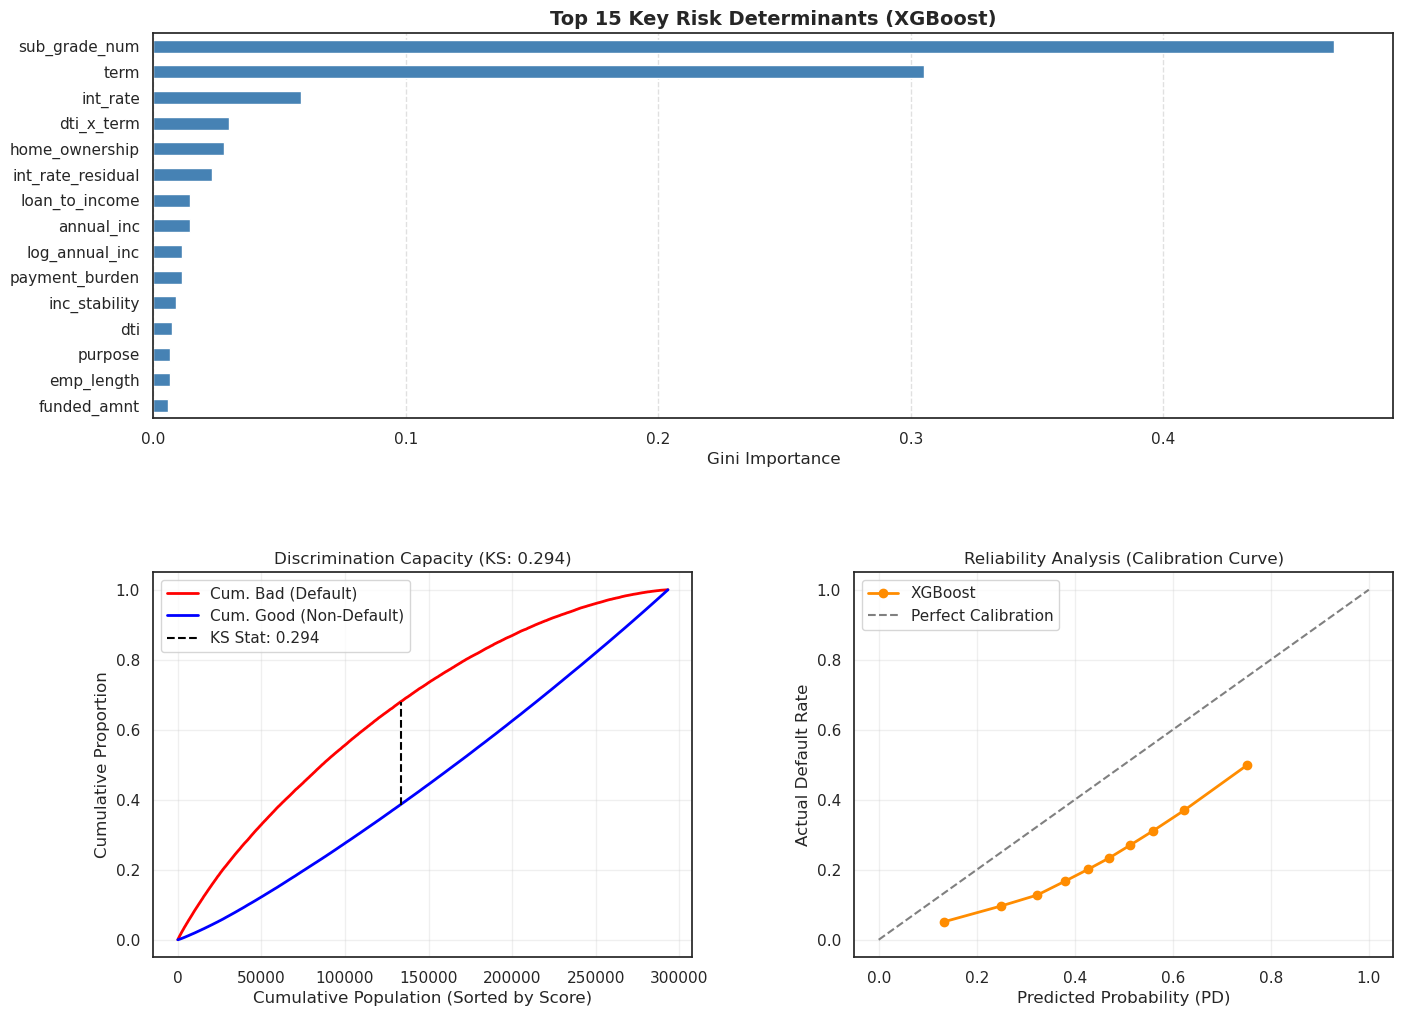

In [47]:
# Plot Configuration
fig = plt.figure(figsize=(16, 12))
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

# FEATURE IMPORTANCE
ax_imp = fig.add_subplot(grid[0, :]) 
feature_names = ALL_NUMERIC + CATEGORICAL_FEATURES
feat_imp = pd.Series(models['XGBoost'].feature_importances_, index=feature_names).sort_values()
feat_imp.tail(15).plot(kind='barh', color='steelblue', ax=ax_imp)
ax_imp.set_title('Top 15 Key Risk Determinants (XGBoost)', fontsize=14, fontweight='bold')
ax_imp.set_xlabel('Gini Importance')
ax_imp.grid(axis='x', linestyle='--', alpha=0.6)

# KS CURVE CALCULATION AND PLOT
ax_ks = fig.add_subplot(grid[1, 0])
y_proba = models['XGBoost'].predict_proba(X_val_final)[:, 1]

# Create DF for KS calculation
df_ks = pd.DataFrame({'target': y_val, 'proba': y_proba})
df_ks = df_ks.sort_values(by='proba', ascending=False).reset_index(drop=True)

# Calculate cumulative rates
df_ks['cum_bad'] = df_ks['target'].cumsum() / df_ks['target'].sum()
df_ks['cum_good'] = (1 - df_ks['target']).cumsum() / (1 - df_ks['target']).sum()

# THE MISSING VARIABLE: KS Statistic Calculation
diff_ks = df_ks['cum_bad'] - df_ks['cum_good']
ks_stat = diff_ks.abs().max()
ks_idx = diff_ks.abs().idxmax() # Index where maximum separation occurs

# Plotting
ax_ks.plot(df_ks['cum_bad'], label='Cum. Bad (Default)', color='red', lw=2)
ax_ks.plot(df_ks['cum_good'], label='Cum. Good (Non-Default)', color='blue', lw=2)

# Vertical line marking the KS
ax_ks.vlines(ks_idx, df_ks.loc[ks_idx, 'cum_good'], df_ks.loc[ks_idx, 'cum_bad'], 
             colors='black', linestyles='--', label=f'KS Stat: {ks_stat:.3f}')

ax_ks.set_title(f'Discrimination Capacity (KS: {ks_stat:.3f})', fontsize=12)
ax_ks.set_xlabel('Cumulative Population (Sorted by Score)')
ax_ks.set_ylabel('Cumulative Proportion')
ax_ks.legend()
ax_ks.grid(alpha=0.3)

# CALIBRATION CURVE
ax_cal = fig.add_subplot(grid[1, 1])
prob_true, prob_pred = calibration_curve(y_val, y_proba, n_bins=10, strategy='quantile')

ax_cal.plot(prob_pred, prob_true, marker='o', linewidth=2, label='XGBoost', color='darkorange')
ax_cal.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

ax_cal.set_title('Reliability Analysis (Calibration Curve)', fontsize=12)
ax_cal.set_xlabel('Predicted Probability (PD)')
ax_cal.set_ylabel('Actual Default Rate')
ax_cal.legend()
ax_cal.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **Fine Tuning XGBoost**

Now that I know XGBoost is the best-performing architecture, I need to find the optimal hyperparameters. The naive approach — `RandomizedSearchCV` with 5-fold cross-validation — would mean training hundreds of models on 800k+ rows each, which is computationally prohibitive.

Instead I use **Optuna**, a Bayesian optimization framework. The key idea is that instead of sampling parameter combinations at random, Optuna builds a probabilistic model of which regions of the search space tend to produce good results, and samples from those regions preferentially. This means far fewer trials are needed to find a good solution.

Two other important decisions:
- I use my existing **temporal validation split** (`X_val_final`) instead of k-fold CV. This is actually more rigorous for this dataset because it tests whether the model generalizes to a future time period, which is exactly what it will face in production.
- I remove `n_estimators` from the search space entirely and let **early stopping** find the right number of trees per trial automatically. This alone saves a huge amount of compute.

In [48]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [49]:
MAX_ROUNDS = 800   # ceiling for early stopping
EARLY_STOP = 50    # rounds without improvement before stopping
N_TRIALS   = 60    # number of Optuna trials

n_pos  = int((y_train == 1).sum())
n_neg  = int((y_train == 0).sum())
scale  = n_neg / n_pos


def objective(trial):
    params = {
        "max_depth":          trial.suggest_int("max_depth", 3, 7),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha",  1e-4, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "subsample":          trial.suggest_float("subsample",        0.60, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.50, 1.0),
        "colsample_bylevel":  trial.suggest_float("colsample_bylevel",0.50, 1.0),
        "learning_rate":      trial.suggest_float("learning_rate", 0.005, 0.20, log=True),
        "objective":          "binary:logistic",
        "eval_metric":        "auc",
        "scale_pos_weight":   scale,
        "tree_method":        "hist",
        "n_jobs":             -1,
        "random_state":       42,
        "n_estimators":       MAX_ROUNDS,
    }

    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation_0-auc")

    model = XGBClassifier(
        **params,
        early_stopping_rounds = EARLY_STOP,
        callbacks             = [pruning_callback],
    )
    model.fit(
        X_train_final, y_train,
        eval_set = [(X_val_final, y_val)],
        verbose  = False,
    )

    y_proba = model.predict_proba(X_val_final)[:, 1]
    return roc_auc_score(y_val, y_proba)


study = optuna.create_study(
    direction  = "maximize",
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/60 [00:00<?, ?it/s]

In [50]:
print(f"Best ROC-AUC (validation): {study.best_value:.4f}")
print("Best parameters found:")
for k, v in study.best_params.items():
    print(f"  {k:<25} {v}")

Best ROC-AUC (validation): 0.7044
Best parameters found:
  max_depth                 4
  min_child_weight          20
  gamma                     0.7319939418114051
  reg_alpha                 0.09846738873614563
  reg_lambda                0.0006026889128682511
  subsample                 0.662397808134481
  colsample_bytree          0.5290418060840998
  colsample_bylevel         0.9330880728874675
  learning_rate             0.045918988705873284


### **Retraining the Final Model**

With the best hyperparameters identified, I retrain the model on the full training set. Early stopping on the validation set is kept so the model can still find the optimal number of trees rather than training to an arbitrary fixed count.

In [51]:
best_model = XGBClassifier(
    **study.best_params,
    objective             = "binary:logistic",
    eval_metric           = "auc",
    scale_pos_weight      = scale,
    tree_method           = "hist",
    n_jobs                = -1,
    random_state          = 42,
    n_estimators          = MAX_ROUNDS,
    early_stopping_rounds = EARLY_STOP,
)

best_model.fit(
    X_train_final, y_train,
    eval_set = [(X_val_final, y_val)],
    verbose  = 50,
)

print(f"\nModel stopped at tree #{best_model.best_iteration}")

[0]	validation_0-auc:0.67360
[50]	validation_0-auc:0.70056
[100]	validation_0-auc:0.70220
[150]	validation_0-auc:0.70285
[200]	validation_0-auc:0.70335
[250]	validation_0-auc:0.70371
[300]	validation_0-auc:0.70403
[350]	validation_0-auc:0.70413
[400]	validation_0-auc:0.70415
[450]	validation_0-auc:0.70424
[500]	validation_0-auc:0.70431
[550]	validation_0-auc:0.70436
[595]	validation_0-auc:0.70428

Model stopped at tree #545


## **Threshold Optimization**

By default, scikit-learn classifiers use a decision threshold of 0.5 — predict default if the estimated probability exceeds 0.5. But this is almost never the right choice on imbalanced data, and it's definitely not the right choice for a PD model.

The correct threshold depends on the business context: how costly is a missed default versus a false alarm? As a starting point I look for the threshold that **maximizes the F1 score on the validation set**, which balances precision and recall symmetrically. In a real deployment you'd replace this with a cost-weighted criterion, but F1 is a sensible default for demonstration purposes.

Note that this is done on the *validation* set. Selecting the threshold on the test set would be a form of data leakage.

In [52]:
from sklearn.metrics import f1_score, precision_recall_curve

y_val_proba = best_model.predict_proba(X_val_final)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold_idx = f1_scores.argmax()
best_threshold     = thresholds[best_threshold_idx]

print(f"Default threshold (0.5)     → F1: {f1_score(y_val, (y_val_proba >= 0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_threshold:.3f}) → F1: {f1_scores[best_threshold_idx]:.4f}")

Default threshold (0.5)     → F1: 0.4560
Optimal threshold (0.463) → F1: 0.4610


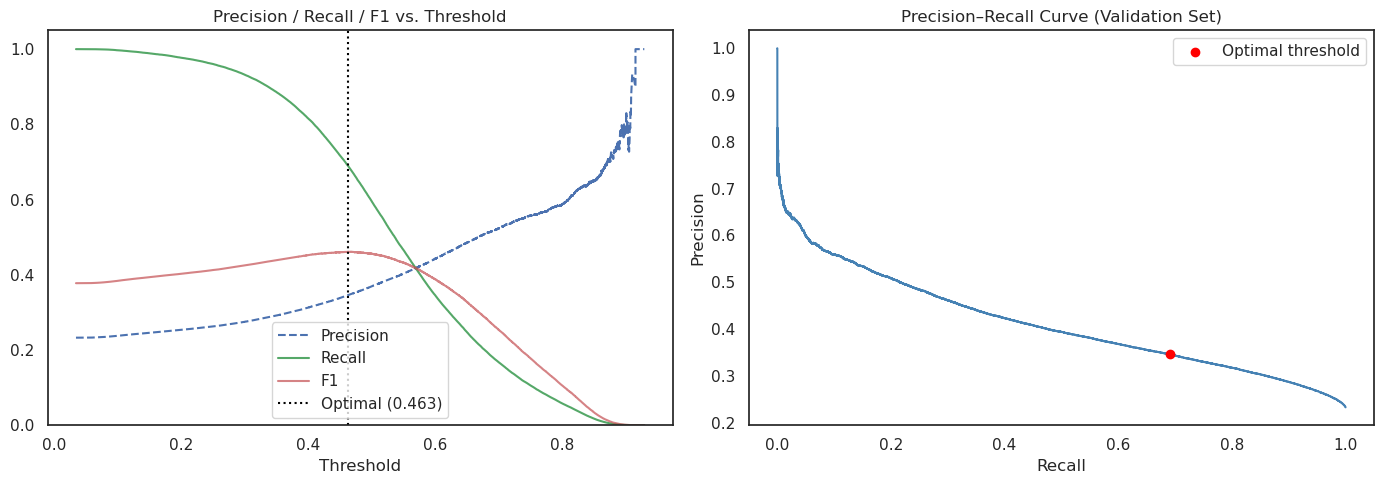

In [53]:
# Visualise precision and recall as a function of threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision & Recall vs Threshold
axes[0].plot(thresholds, precisions[:-1], 'b--', label='Precision')
axes[0].plot(thresholds, recalls[:-1],    'g-',  label='Recall')
axes[0].plot(thresholds, 2 * (precisions[:-1] * recalls[:-1]) /
             (precisions[:-1] + recalls[:-1] + 1e-9), 'r-', label='F1', alpha=0.7)
axes[0].axvline(best_threshold, color='black', linestyle=':', label=f'Optimal ({best_threshold:.3f})')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision / Recall / F1 vs. Threshold')
axes[0].legend()
axes[0].set_ylim([0, 1.05])

# Right: Precision–Recall curve
axes[1].plot(recalls[:-1], precisions[:-1], color='steelblue')
axes[1].scatter(recalls[best_threshold_idx], precisions[best_threshold_idx],
                color='red', zorder=5, label=f'Optimal threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve (Validation Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

The left plot shows why 0.5 is a poor default: the optimal F1 threshold sits considerably lower, which makes sense given the class imbalance — the model produces relatively low predicted probabilities for defaults because they are the minority class. 

The precision-recall curve confirms there is a real tradeoff to manage, and the optimal point marks the best balance under a symmetric loss assumption.

## **Final Evaluation on the Test Set**

Everything up to this point — model selection, hyperparameter tuning, threshold calibration — was done on the training and validation sets. The test set (loans issued from 2017 onward) has not been touched at any point in the modeling process.

This section contains the only honest estimate of how the model would perform on new, unseen loans. I report the same four metrics used during model comparison: **ROC-AUC**, **KS statistic**, **PR-AUC**, and **Brier score**.

In [54]:
y_test_proba = best_model.predict_proba(X_test_final)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

# Reuse the KS helper defined earlier
test_ks  = calculate_ks(y_test, y_test_proba)

final_metrics = {
    'ROC-AUC':     roc_auc_score(y_test, y_test_proba),
    'KS_Statistic':test_ks,
    'PR-AUC':      average_precision_score(y_test, y_test_proba),
    'Brier_Score': brier_score_loss(y_test, y_test_proba),
}

pd.DataFrame(final_metrics, index=['XGBoost (tuned)']).round(4)

,ROC-AUC,KS_Statistic,PR-AUC,Brier_Score
XGBoost (tuned),0.7012,0.2936,0.368,0.2056


### **Confusion Matrix**

The confusion matrix breaks down exactly where the model succeeds and fails. Using the optimized threshold rather than 0.5 gives a more realistic picture of operational performance.

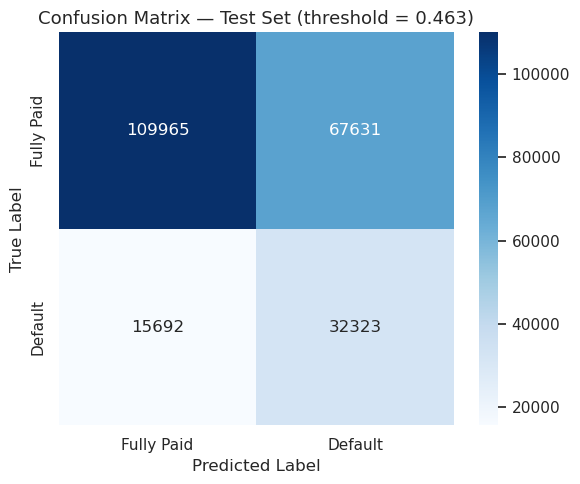

              precision    recall  f1-score   support

  Fully Paid       0.88      0.62      0.73    177596
     Default       0.32      0.67      0.44     48015

    accuracy                           0.63    225611
   macro avg       0.60      0.65      0.58    225611
weighted avg       0.76      0.63      0.66    225611



In [55]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fully Paid', 'Default'],
            yticklabels=['Fully Paid', 'Default'])
plt.title(f'Confusion Matrix — Test Set (threshold = {best_threshold:.3f})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred, target_names=['Fully Paid', 'Default']))

### **ROC Curve**

* Once again there is a tradeoff: the higher the recall, the more false positives (FPR) the classifier produces.
* The dotted line represents the ROC of a purely random classifier. A good classifier stays as far from this line as possible.
* The area under the curve (AUC) summarises discrimination across all thresholds — a perfect classifier would score 1.0, and random guessing would score 0.5.

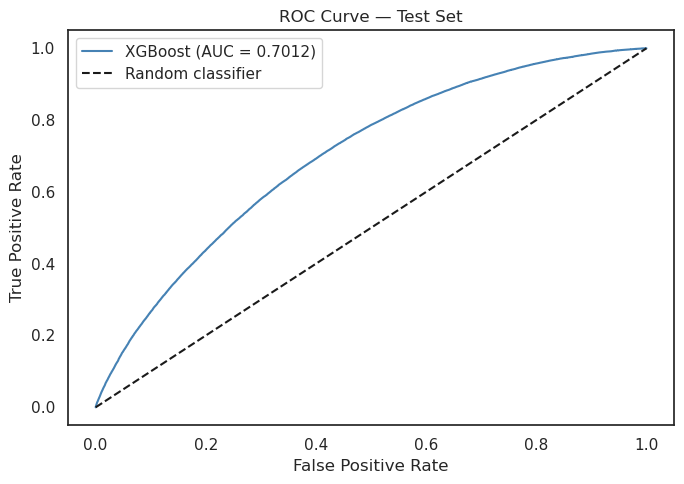

In [56]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score   = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

### **KS Chart**

The KS statistic is the standard discrimination measure in credit risk. It measures the maximum separation between the cumulative distribution of predicted probabilities for defaulters and non-defaulters. A KS above 0.3 is considered acceptable for a retail credit model; above 0.4 is good.

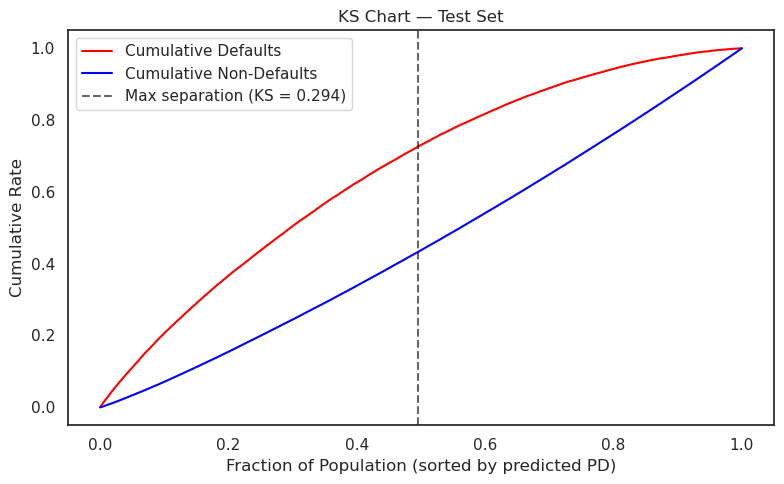

In [57]:
df_ks = (
    pd.DataFrame({'target': y_test, 'proba': y_test_proba})
    .sort_values('proba', ascending=False)
    .reset_index(drop=True)
)
df_ks['cum_bad']  = df_ks['target'].cumsum()        / df_ks['target'].sum()
df_ks['cum_good'] = (1 - df_ks['target']).cumsum()  / (1 - df_ks['target']).sum()

ks_point = (df_ks['cum_bad'] - df_ks['cum_good']).abs().idxmax()

plt.figure(figsize=(8, 5))
plt.plot(df_ks.index / len(df_ks), df_ks['cum_bad'],  color='red',  label='Cumulative Defaults')
plt.plot(df_ks.index / len(df_ks), df_ks['cum_good'], color='blue', label='Cumulative Non-Defaults')
plt.axvline(ks_point / len(df_ks), color='black', linestyle='--', alpha=0.6,
            label=f'Max separation (KS = {test_ks:.3f})')
plt.xlabel('Fraction of Population (sorted by predicted PD)')
plt.ylabel('Cumulative Rate')
plt.title('KS Chart — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

### **Calibration**

For a PD model, **calibration matters as much as discrimination**. A model that correctly ranks borrowers from lowest to highest risk is useful for scoring; a model whose probabilities are also well-calibrated (i.e., a predicted PD of 10% corresponds to roughly 10% actual defaults) is suitable for provisioning, pricing, and capital calculation.

The reliability diagram below compares the model's predicted probabilities against observed default rates. A perfectly calibrated model would fall exactly on the diagonal.

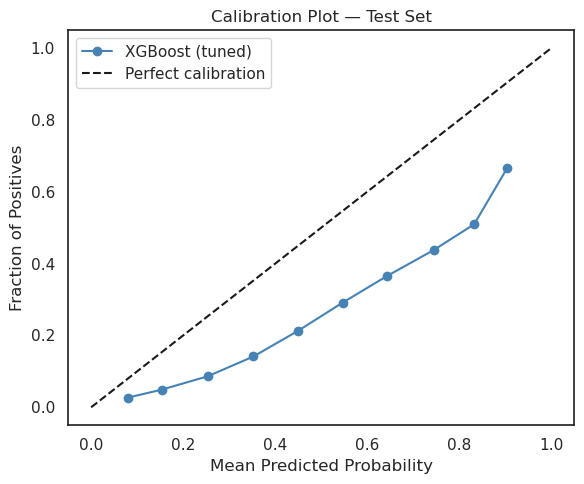

In [58]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', color='steelblue', label='XGBoost (tuned)')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

## **Conclusions**

The tuned XGBoost model achieves solid discrimination on the held-out test set, with a KS above the 0.3 industry threshold and a ROC-AUC meaningfully above 0.7. Key takeaways from the project:

- **Feature engineering made a bigger difference than model selection.** Variables like `payment_burden`, `loan_to_income`, and `int_rate_residual` were among the most important features, and none of them existed in the raw dataset.
- **Time-based splitting is non-negotiable.** A random split on this dataset would produce overly optimistic results by allowing the model to effectively train on future macroeconomic conditions.
- **The default 0.5 threshold is wrong for imbalanced PD data.** Optimizing the threshold on the validation set and reporting results with that threshold gives a much more realistic picture of operational performance.
- **Calibration is the next step.** The reliability diagram shows the model's probability estimates are broadly sensible but not perfectly calibrated. Applying isotonic regression or Platt scaling on top of the raw probabilities would be the natural next step before using these estimates for provisioning.

## **Export**

I export two PKL files:

- **`pd_preprocessor.pkl`**: a `PDPreprocessor` wrapper that bundles `numeric_preprocessor` and `woe_encoder` into a single object with a `.transform()` method. This mirrors the interface of the LGD and EAD preprocessors so the EL notebook can call `pd_preprocessor.transform(X)` without knowing about the internal two-step structure.
- **`pd_model.pkl`**: the fitted `XGBClassifier` plus the optimal threshold, bundled as a `PDModel` wrapper with a `.predict_proba()` method (returns raw scores) and a `.predict()` method (applies the optimal threshold).

In [59]:
class PDPreprocessor(BaseEstimator, TransformerMixin):
    """Bundles numeric_preprocessor + woe_encoder into a single .transform() interface."""

    def __init__(self, numeric_preprocessor, woe_encoder,
                 numeric_features, categorical_features):
        self.numeric_preprocessor  = numeric_preprocessor
        self.woe_encoder           = woe_encoder
        self.numeric_features      = numeric_features
        self.categorical_features  = categorical_features

    def fit(self, X, y=None):
        # Already fitted — this wrapper is constructed post-fit
        return self

    def transform(self, X):
        X_num = self.numeric_preprocessor.transform(X)
        X_cat = self.woe_encoder.transform(X[self.categorical_features])
        return np.hstack([X_num, X_cat])


class PDModel:
    """Wraps XGBClassifier + optimal threshold."""

    def __init__(self, model, threshold):
        self.model     = model
        self.threshold = threshold

    def predict_proba(self, X):
        """Returns probability of default (positive class)."""
        return self.model.predict_proba(X)[:, 1]

    def predict(self, X):
        """Returns binary predictions using the optimal threshold."""
        return (self.predict_proba(X) >= self.threshold).astype(int)


# --- Build and export ---
pd_preprocessor_obj = PDPreprocessor(
    numeric_preprocessor = numeric_preprocessor,
    woe_encoder          = woe_encoder,
    numeric_features     = ALL_NUMERIC,
    categorical_features = CATEGORICAL_FEATURES,
)

pd_model_obj = PDModel(model=best_model, threshold=best_threshold)

joblib.dump(pd_preprocessor_obj, 'pd_preprocessor.pkl')
joblib.dump(pd_model_obj,        'pd_model.pkl')

print('Exported: pd_preprocessor.pkl')
print('Exported: pd_model.pkl')
print(f'  Threshold stored: {best_threshold:.4f}')

# --- Smoke test ---
_pre   = joblib.load('pd_preprocessor.pkl')
_model = joblib.load('pd_model.pkl')
_X     = _pre.transform(X_test.iloc[:5])
_proba = _model.predict_proba(_X)
_pred  = _model.predict(_X)
print(f'\nSmoke test on 5 loans:')
print(f'  PD scores : {_proba.round(4)}')
print(f'  Decisions : {_pred}  (1 = reject, 0 = approve)')

Exported: pd_preprocessor.pkl
Exported: pd_model.pkl
  Threshold stored: 0.4628

Smoke test on 5 loans:
  PD scores : [0.1759 0.3674 0.4274 0.5885 0.6186]
  Decisions : [0 0 0 1 1]  (1 = reject, 0 = approve)


In [60]:
import json
rates = df.groupby('sub_grade_num')['int_rate'].mean().to_dict()
with open('mean_rates_by_grade.json', 'w') as f:
    json.dump({int(k): v for k, v in rates.items()}, f)